### Project: Credit Risk Analysis & Loan Default Prediction

## Step 1: Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns 


## Step 2: Load Dataset

In [2]:
df = pd.read_csv("credit_risk_dataset.csv") 
df.head() 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
## Shape 

df.shape

(32581, 12)

In [4]:
## Dataset information

df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
## Null Values count

df.isnull().sum() 

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## Step 3: Feature Engineering 

In [6]:
## Fill missing values in ( person_emp_length ,loan_int_rate ) column

df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].mean())

df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].mean())

In [7]:
## Age above 100

df[df['person_age']>100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.570000,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.860000,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.250000,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,11.011695,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.730000,0,0.00,N,25


* **Ages above 100 years** are unrealistic and are therefore **treated as outliers**.


In [8]:
## Drop Person Age Above 100 

df = df.drop(df[df['person_age']>100].index) 

In [9]:
## Person Employeement Length (Year) above 100

df[df["person_emp_length"]>100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


* Employment lengths **above 100 years** are unrealistic and are therefore **treated as outliers**.


In [10]:
## Drop unrealistic  Employeement Length (Year) above 100

df = df.drop(df[df["person_emp_length"]>80].index)

In [11]:
## Skewed Columns 

num_cols = df.select_dtypes(include='number')
num_cols.skew() 

person_age                    1.944462
person_income                 9.756273
person_emp_length             1.265234
loan_amnt                     1.192024
loan_int_rate                 0.219421
loan_status                   1.364774
loan_percent_income           1.064143
cb_person_cred_hist_length    1.660413
dtype: float64

## Step 4: Explorary Data Analysis

### 1. Age distribution of customers

In [12]:
df['Age_Group'] = pd.cut(
    df["person_age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

df['Age_Group'].value_counts().sort_index() 

Age_Group
18-25    15350
26-35    13763
36-45     2814
46-55      513
56-65      104
65+         30
Name: count, dtype: int64

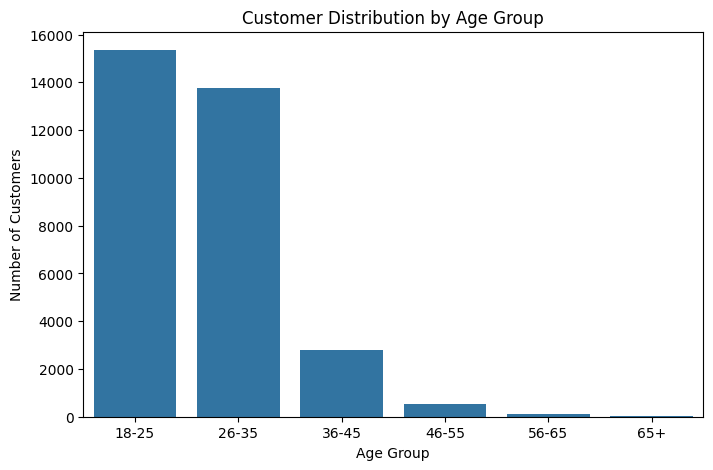

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Age_Group',data= df )

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

* Individuals aged **18 to 35 years** account for the **majority of the loans**.


### 2.  age group distribution  non default VS default  rate

   Loan status (0 is non default 1 is default)

In [14]:
pd.crosstab(
    df['Age_Group'],
    df['loan_status'],
    normalize='index'
) * 100

loan_status,0,1
Age_Group,,
18-25,76.977199,23.022801
26-35,79.321369,20.678631
36-45,79.282161,20.717839
46-55,78.167641,21.832359
56-65,74.038462,25.961538
65+,83.333333,16.666667


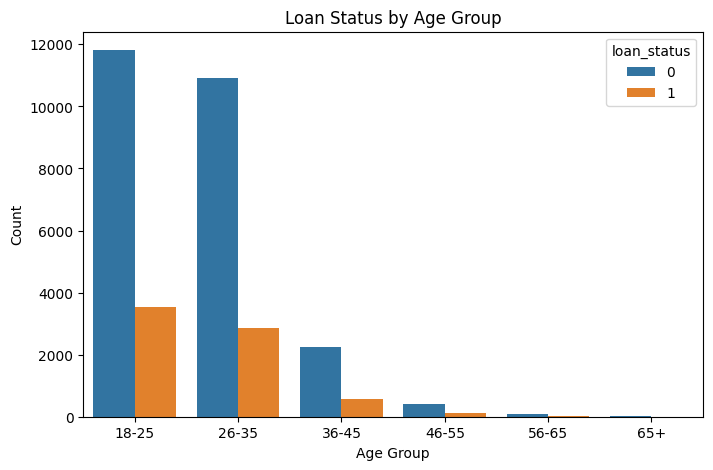

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Age_Group', hue='loan_status')

plt.title('Loan Status by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

### 3. Non Default VS Default distribution 

In [16]:
df['loan_status'].value_counts()

loan_status
0    25467
1     7107
Name: count, dtype: int64

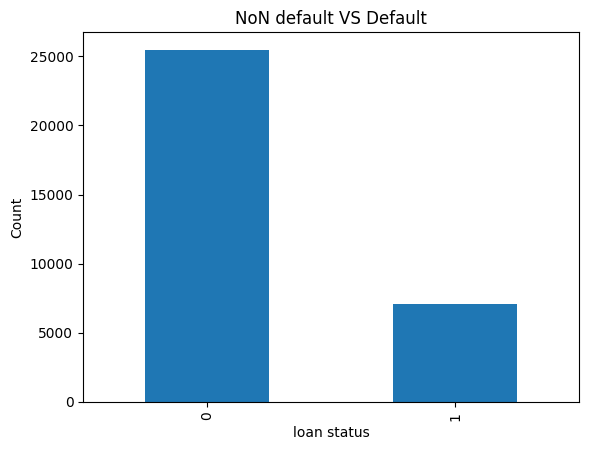

In [17]:
df['loan_status'].value_counts().plot(kind='bar')

plt.title('NoN default VS Default')
plt.xlabel('loan status')
plt.ylabel('Count')
plt.show()

> * The distribution between **non-default and default loans is highly imbalanced**.


### 4. What is the income distribution of customers?

In [18]:
df['person_income'].describe().round(2)

count      32574.00
mean       65878.48
std        52531.94
min         4000.00
25%        38500.00
50%        55000.00
75%        79200.00
max      2039784.00
Name: person_income, dtype: float64

<Axes: xlabel='person_income', ylabel='Count'>

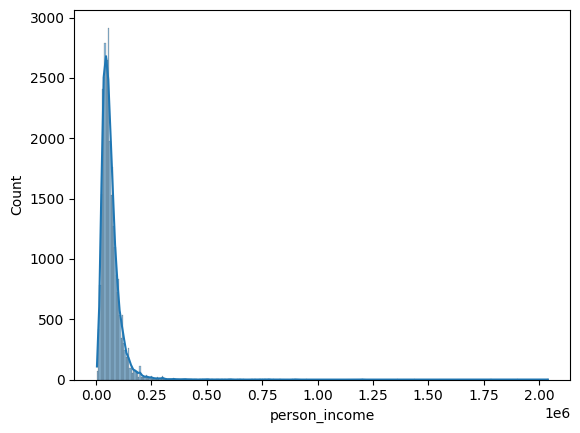

In [19]:
sns.histplot(df['person_income'], kde= True)

### 5. Which home ownership type has the highest loan default?

In [20]:
home_default = (df.groupby('person_home_ownership')['loan_status']
                        .mean()*100
                        ).round(2).sort_values(ascending=True)

home_default

person_home_ownership
OWN          7.47
MORTGAGE    12.57
OTHER       30.84
RENT        31.57
Name: loan_status, dtype: float64

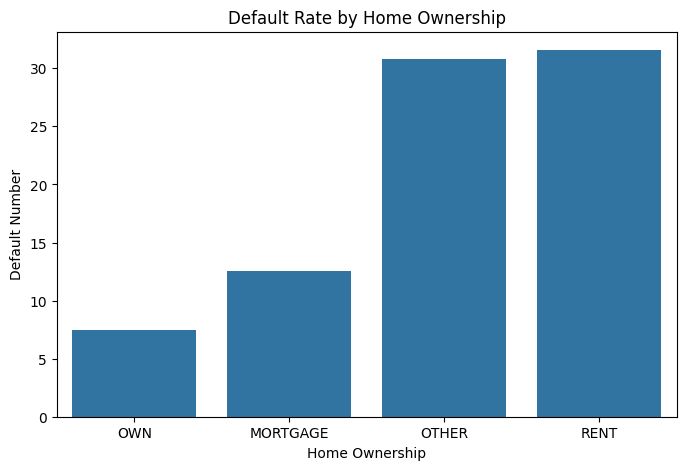

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=home_default.index,
    y=home_default.values
)

plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Number')
plt.show()

* **RENT** home ownership has the **highest loan default rate**, at **31.57%**, while **OWN** home ownership has the **lowest default rate**, at **7.47%**.


### 6. Which loan intent/purpose has the highest %?

In [22]:
loan_intent =  df.groupby('loan_intent').size() 
     
loan_intent_pct = loan_intent/loan_intent.sum()*100

loan_intent_pct

loan_intent
DEBTCONSOLIDATION    16.000491
EDUCATION            19.804138
HOMEIMPROVEMENT      11.067109
MEDICAL              18.637564
PERSONAL             16.942961
VENTURE              17.547737
dtype: float64

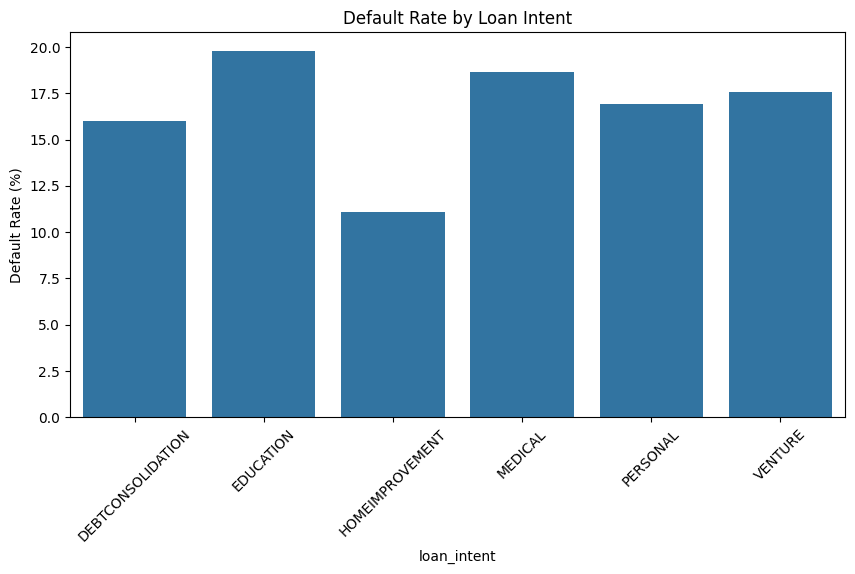

In [23]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=loan_intent_pct.index,
    y=loan_intent_pct.values
)

plt.xticks(rotation=45)
plt.title('Default Rate by Loan Intent')
plt.ylabel('Default Rate (%)')
plt.show()

* **Education** and **Medical** loans have **higher default rates**, while **Home Improvement** loans have a **lower default rate**.


### 7. Which loan grade is most risky?

In [24]:
grade_default = (
    df.groupby('loan_grade')['loan_status']
      .mean()*100
      
).round(2).sort_values(ascending= True)

grade_default

loan_grade
A     9.96
B    16.28
C    20.74
D    59.03
E    64.42
F    70.54
G    98.44
Name: loan_status, dtype: float64

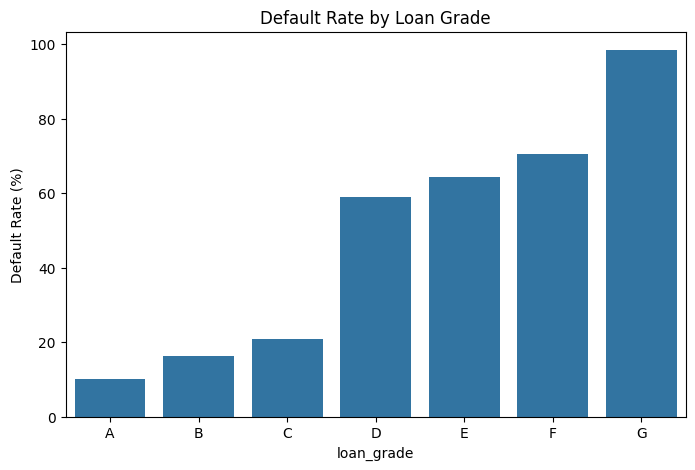

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=grade_default.index,
    y=grade_default.values
)

plt.title('Default Rate by Loan Grade')
plt.ylabel('Default Rate (%)')
plt.show()

* **Loan Grade G** has the **highest default rate**, at **98.44%**, while **Loan Grade A** has the **lowest default rate**, at **9.96%**.


### 8. What is the overall default rate?

In [26]:
default = df['loan_status'].sum()

loan_num = df['loan_status'].count()

default_rate = (default/loan_num)*100

print(f"Overall Default Rate: {default_rate:.2f}%") 

Overall Default Rate: 21.82%


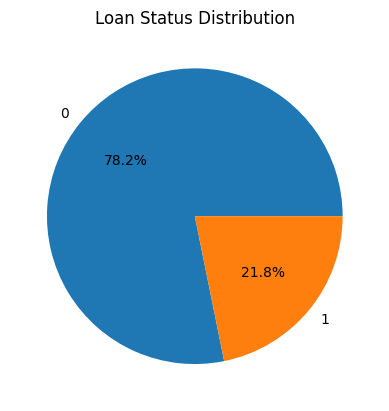

In [27]:
df['loan_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Loan Status Distribution')
plt.ylabel('')
plt.show() 

* Overall, **21.8% of loans resulted in default**.


### 9. How does loan amount affect default?

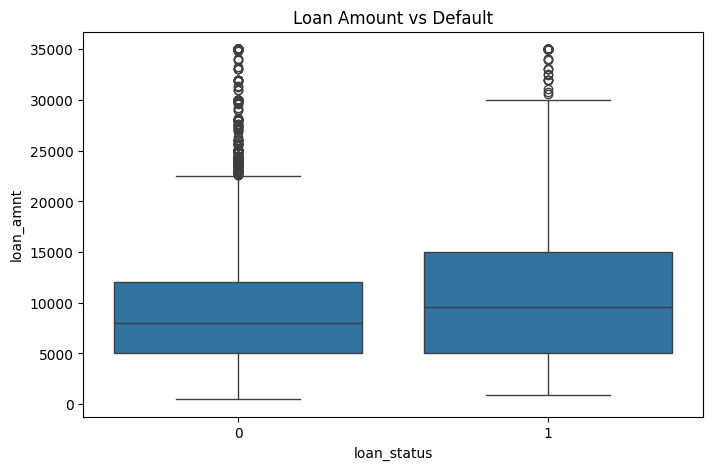

In [28]:
df.groupby('loan_status')['loan_amnt'].mean()

plt.figure(figsize=(8,5))
sns.boxplot(
    x='loan_status',
    y='loan_amnt',
    data=df
)

plt.title('Loan Amount vs Default')
plt.show() 

### 10. Do customers with higher interest rates default more?

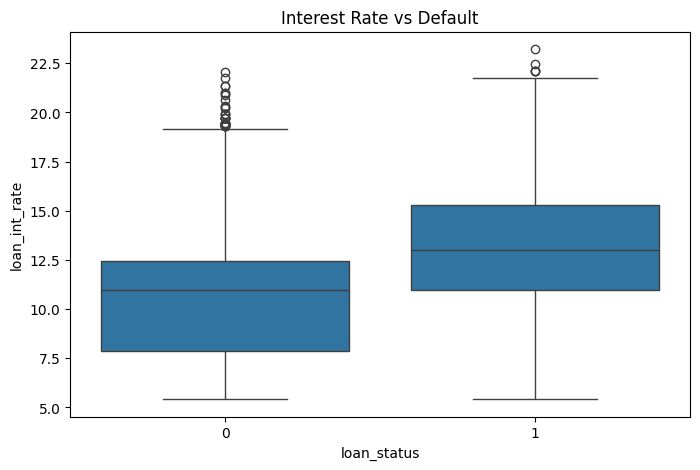

In [29]:
df.groupby('loan_status')['loan_int_rate'].mean()

plt.figure(figsize=(8,5))
sns.boxplot(
    x='loan_status',
    y='loan_int_rate',
    data=df
)

plt.title('Interest Rate vs Default')
plt.show() 

### 11. Do customers with higher loan_percent_income default more often?

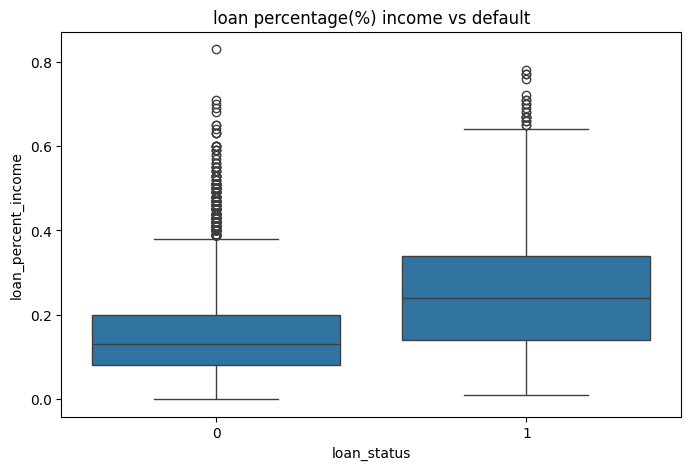

In [30]:
df.groupby('loan_status')['loan_percent_income'].mean()

plt.figure(figsize= (8,5))
sns.boxplot(
    x= 'loan_status',
    y= 'loan_percent_income',
    data=df
)

plt.title('loan percentage(%) income vs default')
plt.show()

## 12. Does employment length affect loan default?

In [31]:
emp_default = (
    df.groupby('person_emp_length')['loan_status']
      .mean()*100
) 

emp_default 

person_emp_length
0.000000      27.941535
1.000000      27.650086
2.000000      25.649688
3.000000      20.138889
4.000000      21.239554
4.789686      31.508380
5.000000      18.601494
6.000000      18.754689
7.000000      18.769932
8.000000      16.656787
9.000000      17.849305
10.000000     17.097701
11.000000     18.378378
12.000000     15.679443
13.000000     11.971831
14.000000     16.716418
15.000000     18.067227
16.000000     12.121212
17.000000     17.054264
18.000000     10.576923
19.000000     14.062500
20.000000     30.952381
21.000000     26.315789
22.000000     15.789474
23.000000     30.000000
24.000000     30.000000
25.000000      0.000000
26.000000     16.666667
27.000000     20.000000
28.000000      0.000000
29.000000    100.000000
30.000000     50.000000
31.000000      0.000000
34.000000    100.000000
38.000000      0.000000
41.000000      0.000000
Name: loan_status, dtype: float64

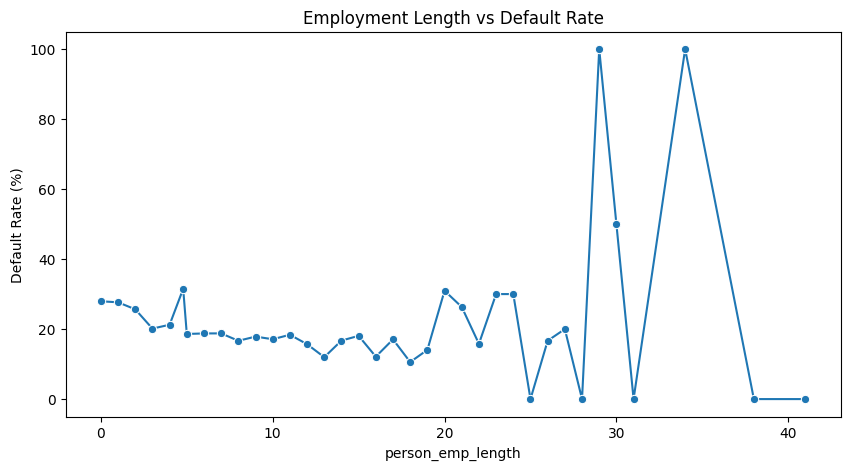

In [32]:
plt.figure(figsize=(10,5))
sns.lineplot(
    x=emp_default.index,
    y=emp_default.values,
    marker='o'
)

plt.title('Employment Length vs Default Rate')
plt.ylabel('Default Rate (%)')
plt.show()

* **Employment length** of **25, 28, 31, 38, and 41 years** shows a **0% default rate**, while employment lengths of **29 and 34 years** show a **100% default rate**.
* These extreme rates may be influenced by **small sample sizes**, so they should be interpreted cautiously.


### 13. Do customers with previous default history default more?

In [33]:
default_history = (
    df.groupby('cb_person_default_on_file')['loan_status']
      .mean()*100
).round(2) 

default_history

cb_person_default_on_file
N    18.4
Y    37.8
Name: loan_status, dtype: float64

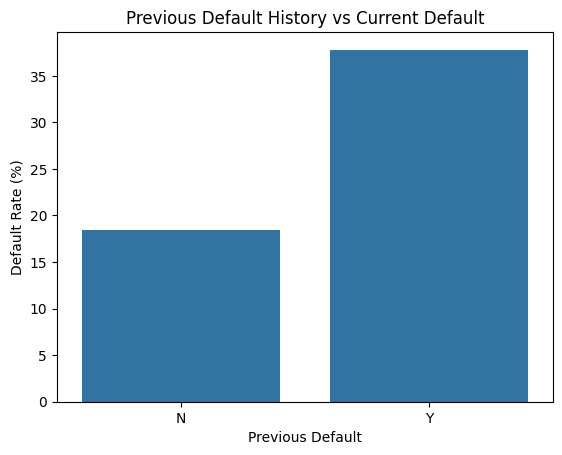

In [34]:
sns.barplot(
    x=default_history.index,
    y=default_history.values
)

plt.title('Previous Default History vs Current Default')
plt.xlabel("Previous Default")
plt.ylabel('Default Rate (%)')
plt.show() 

* Individuals with a **previous default history** have a **37.8% default rate**, which is **19.4 percentage points higher** than those with **no previous default history**.


### 14. What is the default rate by credit history length?

In [35]:
credit_history = (
    df.groupby('cb_person_cred_hist_length')['loan_status']
      .mean()*100
).round(2)

credit_history

cb_person_cred_hist_length
2     23.57
3     22.27
4     22.32
5     20.63
6     20.79
7     19.94
8     21.35
9     20.84
10    20.27
11    20.09
12    20.41
13    19.86
14    21.14
15    21.74
16    21.51
17    19.16
18    21.05
19    23.81
20    29.03
21    30.00
22    27.27
23    13.64
24    20.00
25    29.41
26     6.25
27    36.36
28    33.33
29    42.86
30    22.73
Name: loan_status, dtype: float64

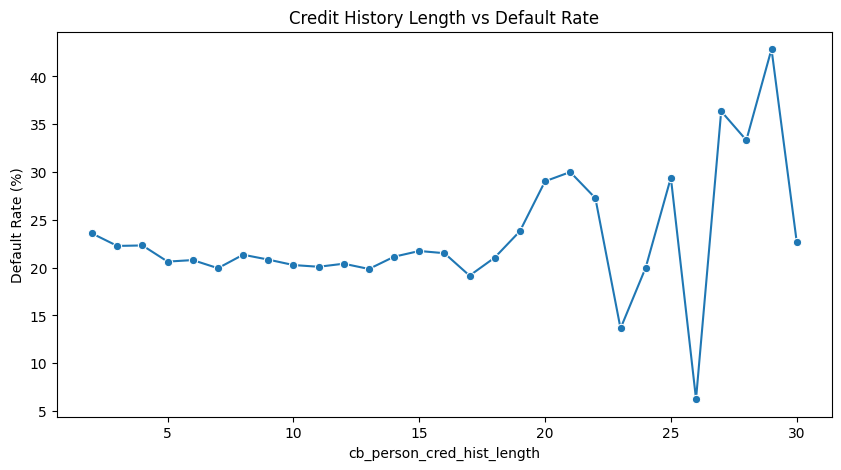

In [36]:
plt.figure(figsize=(10,5))
sns.lineplot(
    x=credit_history.index,
    y=credit_history.values,
    marker='o'
)

plt.title('Credit History Length vs Default Rate')
plt.ylabel('Default Rate (%)')
plt.show()

* A **credit history length of 29 years** has the **highest default rate**, at **42.86%**.
* A **credit history length of 26 years** has the **lowest default rate**, at **6.25%**.


### 15. Which loan intent has the highest average loan amount?

In [37]:
avg_loan = (
    df.groupby('loan_intent')['loan_amnt']
      .mean()
      .sort_values(ascending=False)
).round(2)

avg_loan

loan_intent
HOMEIMPROVEMENT      10360.52
DEBTCONSOLIDATION     9594.89
VENTURE               9580.97
PERSONAL              9569.99
EDUCATION             9481.53
MEDICAL               9259.58
Name: loan_amnt, dtype: float64

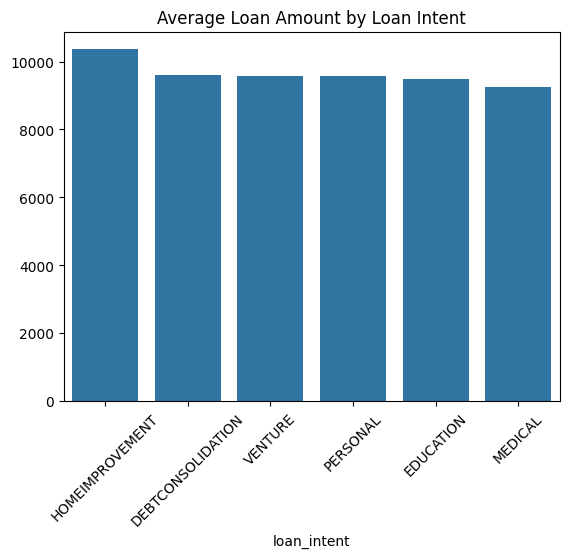

In [38]:

sns.barplot(
    x=avg_loan.index,
    y=avg_loan.values
)

plt.xticks(rotation=45)
plt.title('Average Loan Amount by Loan Intent')
plt.show()

* **HOME IMPROVEMENT** is the loan purpose with the **highest average loan amount**.


### 16. Which loan grade has the highest interest rate?

In [39]:
avg_interest = (
    df.groupby('loan_grade')['loan_int_rate']
      .mean()
).round(2)

avg_interest

loan_grade
A     7.67
B    11.00
C    13.22
D    14.99
E    16.49
F    17.76
G    19.53
Name: loan_int_rate, dtype: float64

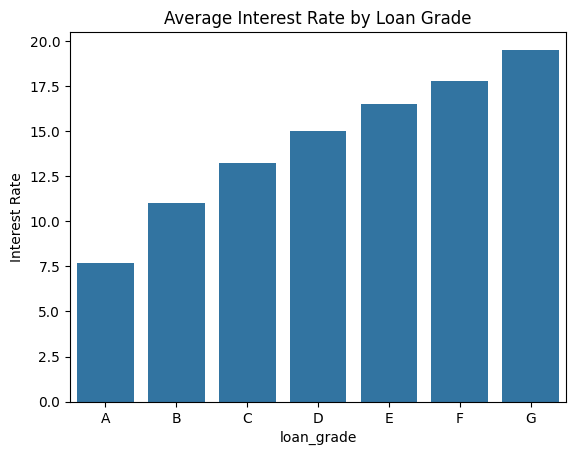

In [40]:

sns.barplot(
    x=avg_interest.index,
    y=avg_interest.values
)

plt.title('Average Interest Rate by Loan Grade')
plt.ylabel('Interest Rate')
plt.show()

>* The **highest interest rate** is associated with **Grade G**, at **19.53%**.
>* The **lowest interest rate** is associated with **Grade A**, at **7.67%**.


### 17. What customer profile is high risk?

In [41]:
risk_profile = df.groupby(
    [
        'person_home_ownership',
        'loan_grade',
        'cb_person_default_on_file'
    ]
)['loan_status'].mean()*100

risk_profile.sort_values(ascending=False).head(20)

person_home_ownership  loan_grade  cb_person_default_on_file
MORTGAGE               G           N                            100.000000
                                   Y                            100.000000
OWN                    G           Y                            100.000000
OTHER                  E           N                            100.000000
                       F           Y                            100.000000
                                   N                            100.000000
RENT                   G           N                            100.000000
OWN                    G           N                            100.000000
RENT                   G           Y                             94.117647
OWN                    F           N                             80.000000
RENT                   E           N                             78.424658
                       F           N                             78.260870
                                   Y   

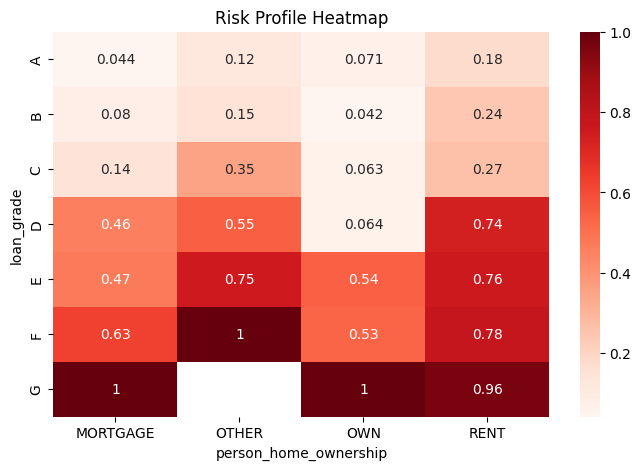

In [42]:
risk_heatmap = pd.pivot_table(
    df,
    values='loan_status',
    index='loan_grade',
    columns='person_home_ownership',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))
sns.heatmap(
    risk_heatmap,
    annot=True,
    cmap='Reds'
)

plt.title('Risk Profile Heatmap')
plt.show()

### 18. Which Factor More influence to Default

<Axes: >

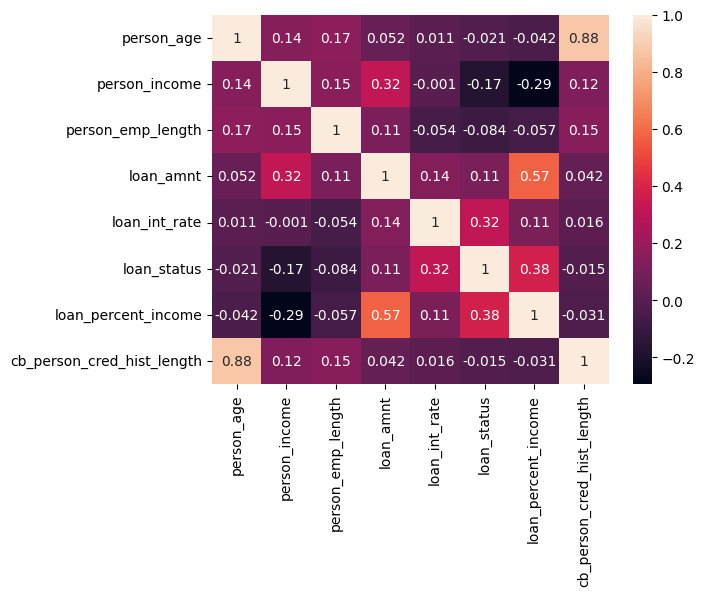

In [43]:
sns.heatmap(df.corr(numeric_only = True), annot= True)

* **Loan amount** has an **11% influence** on the default rate.

* **Loan interest rate** has a **32% influence** on the default rate.

* **Loan amount-to-income percentage** has a **38% influence** on the default rate.

* **Personal income** has a **17% influence** on the non-default rate.


## Step 5. Skewness

 near to 0 > Centralized (0.01, 0.002)

 negative > Left Skewed (-1.56)

 poistive (Toward 1) > Right Skewed (1.256)

In [44]:
num_col = df.select_dtypes(include= 'number')
num_col.skew() 

person_age                    1.944462
person_income                 9.756273
person_emp_length             1.265234
loan_amnt                     1.192024
loan_int_rate                 0.219421
loan_status                   1.364774
loan_percent_income           1.064143
cb_person_cred_hist_length    1.660413
dtype: float64

<Axes: xlabel='person_income', ylabel='Count'>

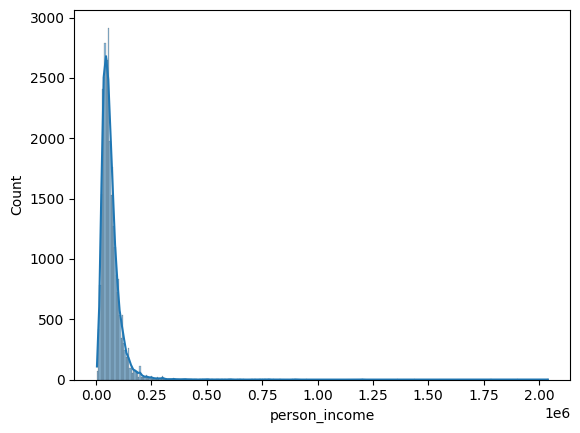

In [45]:
sns.histplot(df['person_income'], kde= True)

## Step 6: Train-Test Split

In [46]:
from sklearn.model_selection import train_test_split 

Skew_cols = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']


Nominial_cols = ['person_home_ownership','loan_intent','cb_person_default_on_file']

Ordinal_cols = ['loan_grade','Age_Group'] 

feature_cols = Skew_cols + Nominial_cols + Ordinal_cols

x = df[feature_cols]

y = df['loan_status']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.30 , random_state= 42)

In [47]:
df['loan_grade'].value_counts()

loan_grade
A    10776
B    10448
C     6456
D     3625
E      964
F      241
G       64
Name: count, dtype: int64

In [48]:
df['Age_Group'].value_counts()

Age_Group
18-25    15350
26-35    13763
36-45     2814
46-55      513
56-65      104
65+         30
Name: count, dtype: int64

## Step 7:  Build a Pipeline and Preprocessing using ColumnTransformer

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

#1. skewed feature
skew_pipeline = Pipeline(steps=[
        ('log_transformer',FunctionTransformer(np.log1p)),
        ('scaler',StandardScaler())
])


loan_grade = ['A','B','C','D','E','F','G']

Age_Group = ['18-25','26-35','36-45','46-55','56-65','65+']

#2. Ordinal feature
ordinal_pipeline = Pipeline(steps=[
    ('encode',OrdinalEncoder(categories=[loan_grade, Age_Group]))
])

#3. Nominal feature
nominal_pipeline = Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

# Column Transformer
preprocessor = ColumnTransformer(transformers=[
    ('skew_pipeline',skew_pipeline,Skew_cols),
    ('ordinal',ordinal_pipeline,Ordinal_cols),
    ('nominal',nominal_pipeline,Nominial_cols)
])

## Step 8: Build Model

### 1. Random Forest

In [50]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


rf_pipeline = Pipeline(steps= [
                ("preprocessor",preprocessor),
                ("Random Forest",RandomForestClassifier(n_estimators = 200,
                                                        criterion = 'log_loss',
                                                        max_depth = 8,
                                                        min_samples_leaf= 50,
                                                        min_samples_split = 50,
                                                        class_weight = 'balanced'))
])


rf_pipeline.fit(x_train,y_train)


rf_predict = rf_pipeline.predict(x_test)

# Evaluate
print("Accuracy score\n",accuracy_score(y_test,rf_predict))

print("Recall\n",recall_score(y_test,rf_predict))

print("Precision\n",precision_score(y_test,rf_predict))

print("\nF1 Score\n",f1_score(y_test ,rf_predict))

print("\nroc_auc_score\n",roc_auc_score(y_test ,rf_predict))

print("\nClassification Report\n",classification_report(y_test ,rf_predict))

print("\nConfusion Matrix\n",confusion_matrix(y_test ,rf_predict))

Accuracy score
 0.8858078379208022
Recall
 0.7843137254901961
Precision
 0.7197943444730077

F1 Score
 0.7506702412868632

roc_auc_score
 0.8493053360775578

Classification Report
               precision    recall  f1-score   support

           0       0.94      0.91      0.93      7631
           1       0.72      0.78      0.75      2142

    accuracy                           0.89      9773
   macro avg       0.83      0.85      0.84      9773
weighted avg       0.89      0.89      0.89      9773


Confusion Matrix
 [[6977  654]
 [ 462 1680]]


### 2. XGBOOST

In [51]:
from xgboost import XGBClassifier 

xg_pipeline = Pipeline(steps= [
                    ("preprocessor",preprocessor),
                    ("XGBOOST",XGBClassifier(n_estimators=200,
                                             max_depth=8,
                                             learning_rate=0.2,
                                             eval_metric="logloss",
                                             random_state=42 ))
])


xg_pipeline.fit(x_train,y_train)

xg_predict = xg_pipeline.predict(x_test)

# Evaluate
print("Accuracy score\n",accuracy_score(y_test,xg_predict))

print("Recall\n",recall_score(y_test,xg_predict))

print("Precision\n",precision_score(y_test,xg_predict))

print("\nF1 Score\n",f1_score(y_test,xg_predict))

print("\nroc_auc_score\n",roc_auc_score(y_test,xg_predict))

print("\nClassification Report\n",classification_report(y_test,xg_predict))

print("\nConfusion Matrix\n",confusion_matrix(y_test,xg_predict))

Accuracy score
 0.938708687199427
Recall
 0.7647058823529411
Precision
 0.9451817657241778

F1 Score
 0.8454193548387097

roc_auc_score
 0.8761283310336321

Classification Report
               precision    recall  f1-score   support

           0       0.94      0.99      0.96      7631
           1       0.95      0.76      0.85      2142

    accuracy                           0.94      9773
   macro avg       0.94      0.88      0.90      9773
weighted avg       0.94      0.94      0.94      9773


Confusion Matrix
 [[7536   95]
 [ 504 1638]]


## Loan Default Prediction – Model Performance

Built a machine learning solution to **identify high-risk borrowers and support credit-risk decision-making**.

| Metric | Random Forest | **XGBoost** |
|---|---:|---:|
| Accuracy | 88.50% | **93.87%** |
| Default Recall | **78.20%** | 76.47% |
| Default Precision | 71.83% | **94.52%** |
| F1-Score | 74.88% | **84.54%** |
| ROC-AUC | 0.848 | **0.876** |

### Key Insights

- **XGBoost achieved 93.87% accuracy and 0.876 ROC-AUC**, demonstrating strong overall classification performance.
- **94.52% precision** means the model's high-risk predictions were highly reliable.
- **76.47% default recall** enabled the model to identify the majority of actual defaulters.
- **F1-score improved from 74.88% → 84.54%**, showing a stronger precision–recall balance.

### Business Impact

> **XGBoost provides a strong credit-risk screening model by accurately identifying high-risk borrowers while reducing false-positive default predictions, supporting more informed lending decisions.**

## Step 9: Save The Model

In [54]:
import joblib

joblib.dump(xg_pipeline,'Loan_Default_Prediction.pkl')


['Loan_Default_Prediction.pkl']